<a href="https://colab.research.google.com/github/alimohmedelsaid26-cell/1000MLEngineer/blob/main/Airline_Passengers_Forecasting_using_LSTM_Deep_Learning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

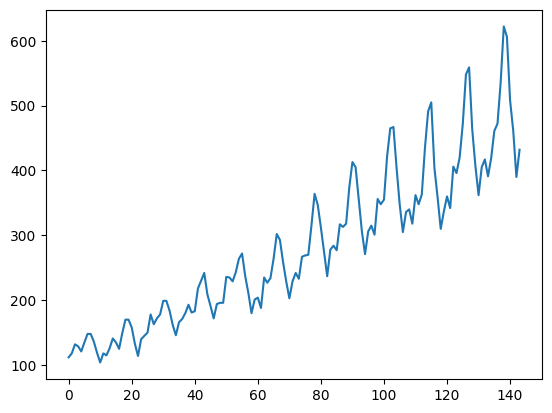

In [10]:
import pandas
import matplotlib.pyplot as plt

# Load the dataset
dataset = pandas.read_csv('/content/airplane-passengers.csv', usecols=[1], engine='python')

# Plot the data to visualize the trend
plt.plot(dataset)
plt.show()

In [11]:
import numpy
import matplotlib.pyplot as plt
import pandas
import math
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# fix random seed for reproducibility
numpy.random.seed(7)

In [12]:
# load the dataset
dataframe = pandas.read_csv('/content/airplane-passengers.csv', usecols=[1], engine='python')
dataset = dataframe.values
dataset = dataset.astype('float32')

In [13]:
# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

In [14]:
# split into train and test sets
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
print(len(train), len(test))

96 48


In [15]:
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return numpy.array(dataX), numpy.array(dataY)

In [16]:
# reshape into X=t and Y=t+1
look_back = 1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# reshape input to be [samples, time steps, features]
trainX = numpy.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = numpy.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [17]:
# create and fit the LSTM network
model = Sequential()
model.add(LSTM(4, input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94/94 - 2s - 24ms/step - loss: 0.0497
Epoch 2/100
94/94 - 0s - 3ms/step - loss: 0.0269
Epoch 3/100
94/94 - 0s - 2ms/step - loss: 0.0200
Epoch 4/100
94/94 - 0s - 2ms/step - loss: 0.0180
Epoch 5/100
94/94 - 0s - 2ms/step - loss: 0.0171
Epoch 6/100
94/94 - 0s - 2ms/step - loss: 0.0165
Epoch 7/100
94/94 - 0s - 2ms/step - loss: 0.0156
Epoch 8/100
94/94 - 0s - 2ms/step - loss: 0.0149
Epoch 9/100
94/94 - 0s - 2ms/step - loss: 0.0142
Epoch 10/100
94/94 - 0s - 2ms/step - loss: 0.0135
Epoch 11/100
94/94 - 0s - 2ms/step - loss: 0.0128
Epoch 12/100
94/94 - 0s - 2ms/step - loss: 0.0117
Epoch 13/100
94/94 - 0s - 2ms/step - loss: 0.0108
Epoch 14/100
94/94 - 0s - 2ms/step - loss: 0.0099
Epoch 15/100
94/94 - 0s - 2ms/step - loss: 0.0090
Epoch 16/100
94/94 - 0s - 2ms/step - loss: 0.0080
Epoch 17/100
94/94 - 0s - 2ms/step - loss: 0.0072
Epoch 18/100
94/94 - 0s - 2ms/step - loss: 0.0064
Epoch 19/100
94/94 - 0s - 2ms/step - loss: 0.0056
Epoch 20/100
94/94 - 0s - 2ms/step - loss: 0.0048
Epoch 21/100
94/94 -

In [19]:
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
# invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])
# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))

testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Train Score: 22.82 RMSE
Test Score: 48.00 RMSE


In [20]:
# shift train predictions for plotting
trainPredictPlot = numpy.empty_like(dataset)
trainPredictPlot[:, :] = numpy.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict

In [21]:
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(dataset)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict

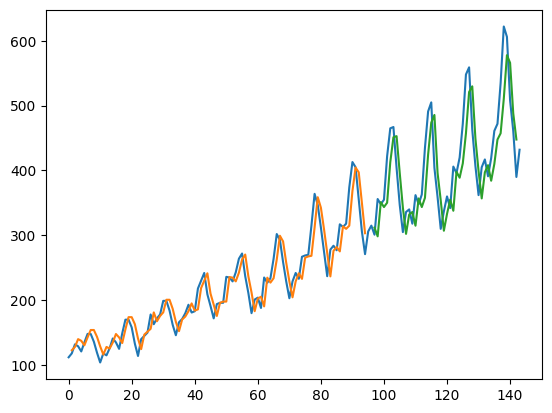

In [22]:
# plot baseline and predictions
plt.plot(scaler.inverse_transform(dataset)) # Original Data (Baseline)
plt.plot(trainPredictPlot)                  # Training Predictions
plt.plot(testPredictPlot)                   # Test Predictions
plt.show()                                  # Display the graph